In [1]:
import math
from pathlib import Path

import matplotlib.pyplot as plt
import polars as pl

In [2]:
load_dir = Path("~/Data/foundata/out")
attributes = pl.read_csv(load_dir / "all_attributes.csv")
trips = pl.read_csv(load_dir / "all_trips.csv")
attributes.head()

hid,pid,age,hh_size,hh_income,sex,dwelling,ownership,vehicles,disability,education,can_wfh,occupation,race,has_licence,relationship,employment,country,source,year,month,day,rurality,weight
str,str,i64,i64,i64,str,str,str,i64,str,str,str,str,str,str,str,str,str,str,i64,str,str,str,f64
"""ltds24127231""","""ltds2412723104""",3,4,129983,"""male""","""unknown""","""unknown""",1,"""unknown""","""unknown""","""n/a""","""n/a""","""unknown""","""no""","""child""","""student""","""uk""","""ltds""",2024,null,"""saturday""","""suburban""",888.083537
"""ltds24057183""","""ltds2405718303""",1,3,null,"""male""","""unknown""","""unknown""",0,"""unknown""","""unknown""","""n/a""","""n/a""","""unknown""","""no""","""child""","""student""","""uk""","""ltds""",2024,null,"""saturday""","""suburban""",1389.686246
"""ltds24261191""","""ltds2426119103""",0,3,73786,"""female""","""unknown""","""unknown""",1,"""unknown""","""unknown""","""n/a""","""n/a""","""unknown""","""no""","""child""","""student""","""uk""","""ltds""",2024,null,"""wednesday""","""suburban""",573.793877
"""ltds24392111""","""ltds2439211107""",2,7,183486,"""female""","""unknown""","""unknown""",2,"""unknown""","""unknown""","""n/a""","""n/a""","""unknown""","""no""","""other""","""student""","""uk""","""ltds""",2024,null,"""tuesday""","""suburban""",490.465951
"""ltds24295273""","""ltds2429527302""",2,2,null,"""female""","""unknown""","""unknown""",0,"""unknown""","""unknown""","""n/a""","""n/a""","""unknown""","""no""","""child""","""student""","""uk""","""ltds""",2024,null,"""monday""","""urban""",1394.780525


In [3]:
import polars as pl

# trips already joined with attributes so that trips["source"] exists
trips = trips.join(attributes.select("pid", "source"), on="pid", how="left")

# trip counts per source
trip_counts = trips.group_by("source").agg(n_trips=pl.len())

# attribute counts per source
attribute_counts = attributes.group_by("source").agg(n_attributes=pl.len())

# join them together
attributes_summary = attribute_counts.join(
    trip_counts, on="source", how="left"
).fill_null(0)

# add total row
total_row = pl.DataFrame(
    {
        "source": ["total"],
        "n_attributes": [attributes.height],
        "n_trips": [trips.height],
    },
    schema={
        "source": pl.String,
        "n_attributes": pl.UInt32,
        "n_trips": pl.UInt32,
    },
)

attributes_summary = pl.concat([attributes_summary, total_row], how="diagonal")

print(attributes_summary)

shape: (7, 3)
┌────────┬──────────────┬─────────┐
│ source ┆ n_attributes ┆ n_trips │
│ ---    ┆ ---          ┆ ---     │
│ str    ┆ u32          ┆ u32     │
╞════════╪══════════════╪═════════╡
│ nts    ┆ 1728067      ┆ 5106905 │
│ vista  ┆ 94821        ┆ 257557  │
│ qhts   ┆ 51481        ┆ 126485  │
│ cmap   ┆ 31540        ┆ 101965  │
│ nhts   ┆ 716376       ┆ 2604832 │
│ ltds   ┆ 71734        ┆ 137900  │
│ total  ┆ 2694019      ┆ 8465280 │
└────────┴──────────────┴─────────┘


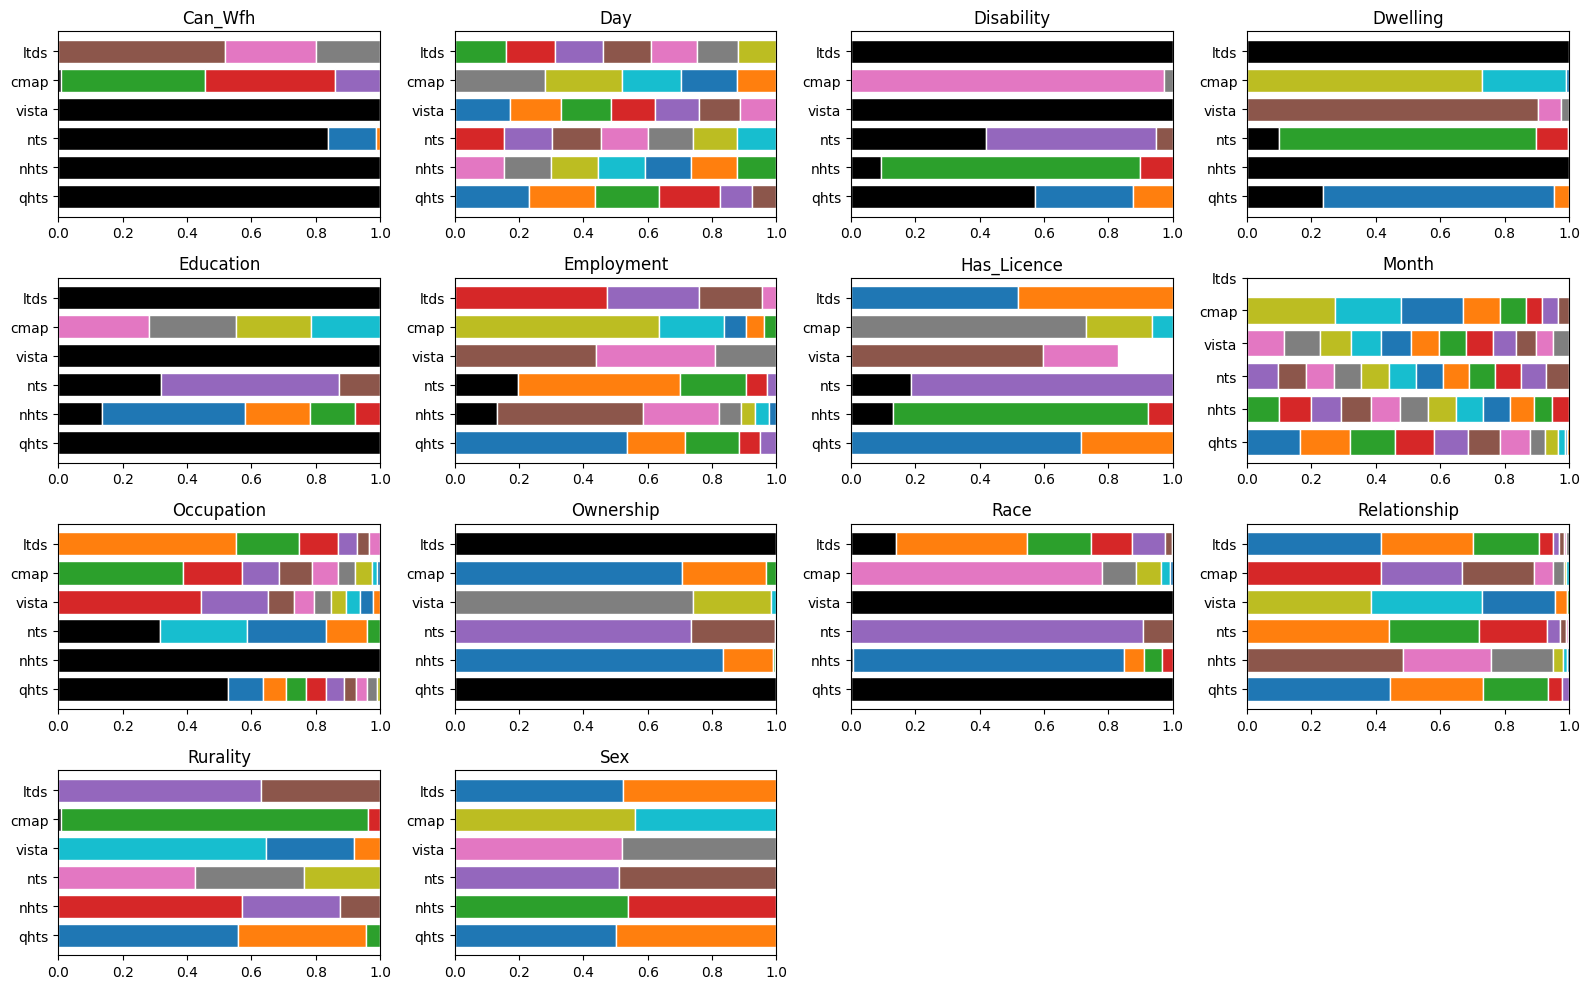

In [9]:
cat_cols = {
    col for col in attributes.columns if attributes[col].dtype == pl.String
} - {"source", "pid", "hid", "country"}

n_cols = 4  # number of columns in tiling (change if needed)
n_plots = len(cat_cols)
n_rows = math.ceil(n_plots / n_cols)

fig, axes = plt.subplots(
    n_rows, n_cols, figsize=(4 * n_cols, 2.5 * n_rows), squeeze=False
)


def plot_column(ax, df: pl.DataFrame, col: str, on: str):

    categories = set(df.select(pl.col(on)).unique().to_series().to_list())

    for i, cat in enumerate(categories):
        sub = df.filter(pl.col(on) == cat)
        proportions = (
            sub[col]
            .value_counts(normalize=True)
            .sort("proportion", descending=True)
        )

        # sort proportions so that "unknown" is always last
        unknown = proportions.filter(
            pl.col(col).str.to_lowercase() == "unknown"
        )
        other = proportions.filter(pl.col(col).str.to_lowercase() != "unknown")
        proportions = unknown.vstack(other)

        left = 0
        for val, prop in proportions.select(col, "proportion").to_numpy():

            if str(val).lower() == "unknown":
                color = "black"
            else:
                color = None

            ax.barh(y=i, width=prop, left=left, color=color, edgecolor="white")
            left += prop

    ax.set_title(col.title())
    ax.set_yticks(range(len(categories)))
    ax.set_yticklabels(categories)
    ax.set_xlim(0, 1)


for idx, col in enumerate(sorted(cat_cols)):

    r = idx // n_cols
    c = idx % n_cols

    ax = axes[r][c]
    plot_column(ax, attributes.sample(n=10000), col, "source")

# Remove empty axes
for i in range(n_plots, n_rows * n_cols):
    r = i // n_cols
    c = i % n_cols
    axes[r][c].axis("off")

plt.tight_layout()
plt.show()